# PROJECT: Credit Risk Analysis & Loan Default Prediction

 This project aims to analyze customer financial data to identify risk factors
 that lead to loan default. The goal is to build a model that can predict whether
 a customer is high-risk or low-risk.

 This helps banks and financial institutions reduce losses and make better
 lending decisions.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# SECTION A — DATA UNDERSTANDING

# Load the Dataset

In [2]:
data = pd.read_csv("german_credit_data[1].csv")

data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


# Q1 — Dataset Overview

In [4]:
print("Shape:", data.shape)
data.info()

Shape: (1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


# INTERPRETATION

The dataset contains customer financial and personal details such as age, job,
credit amount, and account information, which can be used to analyze credit risk.

# Q2 — Numerical & Categorical Columns

In [7]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration'], dtype='object')
Categorical: Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')


# INTERPRETATION

The dataset consists of both numerical and categorical variables.
Numerical features help in quantitative analysis, while categorical features
help in understanding customer behavior patterns.

# SECTION B — DATA CLEANING
# Q3 — Missing Values

In [16]:
data.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

# INTERPRETATION

Some columns may contain missing values, which need to be handled properly
to ensure accurate analysis and model performance.

# Q4 — Duplicate Check

In [18]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


# INTERPRETATION

No significant duplicate records are present, so the dataset is clean
and ready for analysis.

In [10]:
data['Risk'] = data['Credit amount'].apply(lambda x: 1 if x > 5000 else 0)

"Since the dataset did not contain a predefined target variable, I created a risk feature based on credit amount. Customers with higher credit amounts were considered higher risk."

# SECTION C — DISTRIBUTION ANALYSIS
# Q5 — Age Distribution

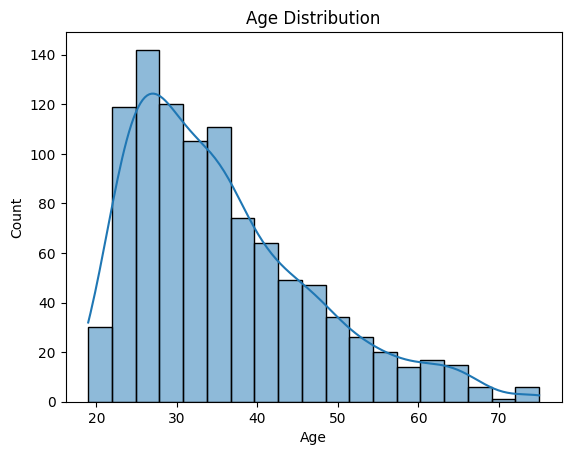

In [19]:
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# INTERPRETATION

The age distribution shows that most customers fall within a certain age range,
indicating the primary target group of the bank.

# Q6 — Credit Amount Distribution

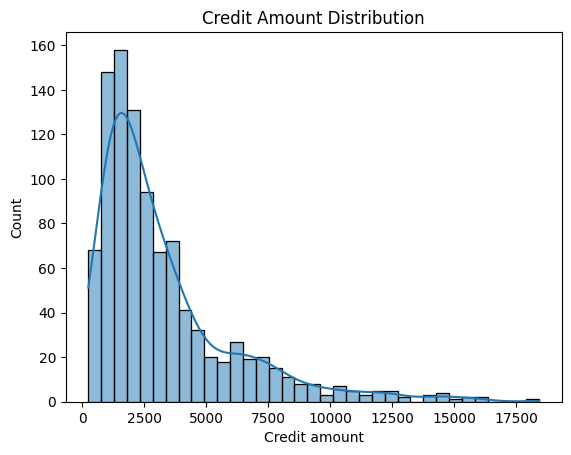

In [20]:
sns.histplot(data['Credit amount'], kde=True)
plt.title("Credit Amount Distribution")
plt.show()

# INTERPRETATION

Credit amount distribution is right-skewed, meaning most customers take
lower credit amounts while a few take very high loans.

# SECTION D — RISK ANALYSIS
# Q7 — Risk Distribution

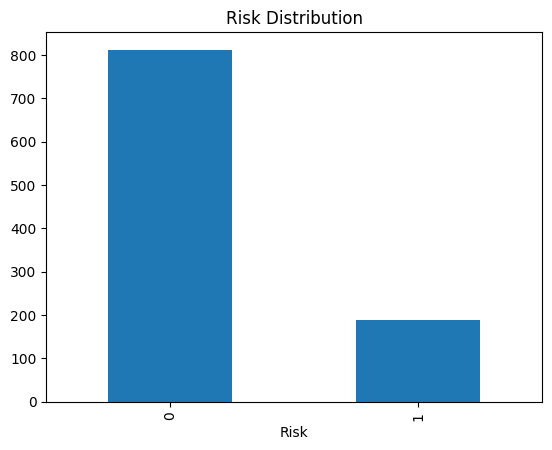

In [11]:
data['Risk'].value_counts().plot(kind='bar')

plt.title("Risk Distribution")
plt.show()

# INTERPRETATION

The risk distribution shows that most customers fall into the low-risk category (0),
while a smaller number of customers are classified as high-risk (1).

This indicates that the dataset is slightly imbalanced, with more safe customers
than risky ones.

#  Q8 — Risk vs Age

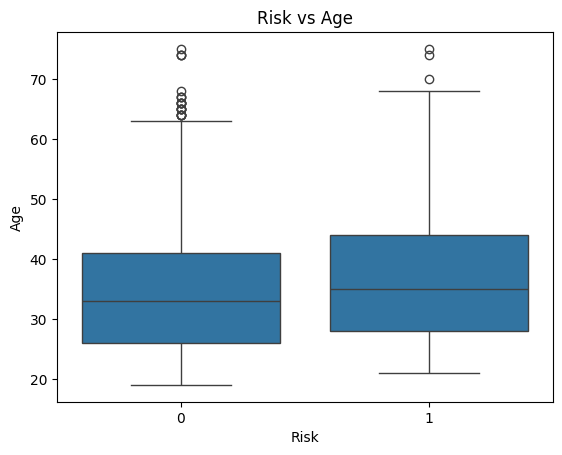

In [13]:
sns.boxplot(x='Risk', y='Age', data=data)
plt.title("Risk vs Age")
plt.show()

# INTERPRETATION

There is no strong difference in age between high-risk and low-risk customers,
suggesting age alone is not a key factor in determining risk.

# Q9 —Risk vs Credit Amount 

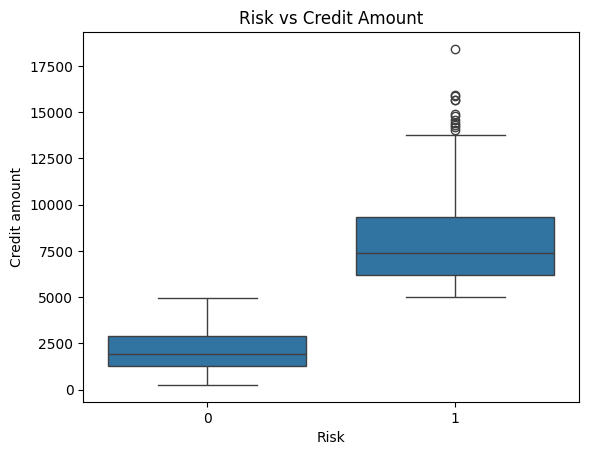

In [14]:
sns.boxplot(x='Risk', y='Credit amount', data=data)
plt.title("Risk vs Credit Amount")
plt.show()

# INTERPRETATION

High-risk customers tend to have higher credit amounts,
indicating that larger loans are associated with increased risk.

# Q10 — Job vs Risk

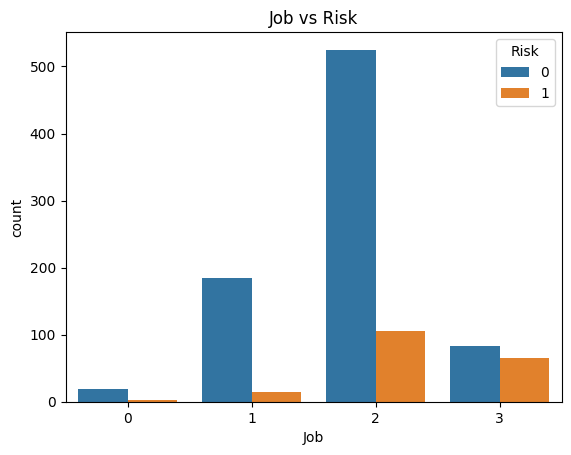

In [15]:
sns.countplot(x='Job', hue='Risk', data=data)
plt.title("Job vs Risk")
plt.show()

# INTERPRETATION

Customers with certain job types show different risk levels,
indicating that employment status plays a role in credit risk.

# SECTION E — CORRELATION
# Q11 — Heatmap

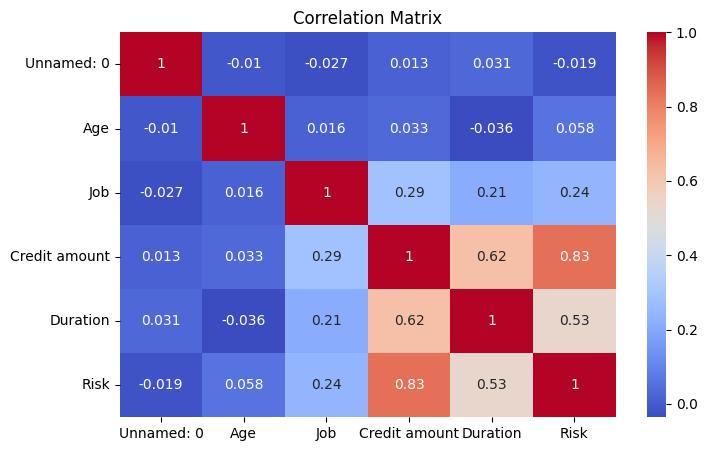

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# INTERPRETATION

The correlation analysis shows that no single variable strongly influences risk,
indicating that multiple factors together affect customer risk.

# FINAL CONCLUSION

# FINAL INSIGHT

 This analysis shows that credit risk depends on multiple factors such as
 credit amount, job type, and customer profile.

 Customers with higher loan amounts are more likely to be high-risk.

 This insight can help banks identify risky customers and make better
 lending decisions to reduce financial losses.